# Data Scaling & Empirical Learning Curve Analysis
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert systematisch das Skalierungsverhalten des **BiLSTM MixUp Simplicity Regressors** entlang zweier zentraler Dimensionen:
1. **MixUp-Multiplikator (`mixtures_per_pair`):** $M \in \{2, 5, 10, 20, 40, 80\}$
2. **Anzahl der Basis-Artikelpaare (`num_train_article_pairs`):** $F \in \{10\%, 25\%, 50\%, 75\%, 100\%\}$

Alle Modelle wurden auf demselben festen, ungesehenen **Test-Split (10%)** evaluiert.

In [1]:
import os
import sys
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sicheres Setzen des Projekt-Wurzelverzeichnisses (sucht nach 'data' und 'scripts')
start_dir = os.getcwd()
while not (os.path.exists("data") and os.path.exists("scripts")):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # Root des Dateisystems erreicht
        os.chdir(start_dir)
    os.chdir("..")

print(f"Projekt-Root: {os.getcwd()}")

# Publication-quality plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

RESULTS_DIR = "results/experiments/data_scaling"
SUMMARY_CSV = os.path.join(RESULTS_DIR, "scaling_summary.csv")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Results-Verzeichnis: {RESULTS_DIR}")
print(f"Plots-Verzeichnis:   {PLOTS_DIR}")

Projekt-Root: /home/fiete/master-thesis
Results-Verzeichnis: results/experiments/data_scaling
Plots-Verzeichnis:   results/experiments/data_scaling/plots


## 1. Daten laden und tabellarische Übersicht

In [2]:
if os.path.exists(SUMMARY_CSV):
    df = pd.read_csv(SUMMARY_CSV)
else:
    # Fallback: Direkt aus den JSON-Dateien einlesen
    json_files = glob.glob(os.path.join(RESULTS_DIR, "*_metrics.json"))
    records = []
    for jf in json_files:
        try:
            with open(jf, "r", encoding="utf-8") as f:
                records.append(json.load(f))
        except Exception as e:
            print(f"Fehler beim Lesen von {jf}: {e}")
    df = pd.DataFrame(records)

if not df.empty:
    display_cols = [
        "experiment_name", "experiment_group", "num_train_article_pairs",
        "mixtures_per_pair", "total_train_samples", "test_mse", "test_mae", "test_r2", "test_binary_acc", "training_time_seconds"
    ]
    df_display = df[[c for c in display_cols if c in df.columns]].sort_values(by=["experiment_group", "total_train_samples"])
    display(df_display)
else:
    print("Noch keine Evaluations-Ergebnisse gefunden. Bitte zuerst die SLURM-Experimente ausführen.")

,experiment_name,experiment_group,num_train_article_pairs,mixtures_per_pair,total_train_samples,test_mse,test_mae,test_r2,test_binary_acc,training_time_seconds
0,scale_mixtures_m2,mixtures_scaling,480,2,960,0.05645,0.18670,0.26708,74.00,3.55
1,scale_mixtures_m5,mixtures_scaling,480,5,2400,0.05130,0.17775,0.33396,74.50,3.91
2,scale_mixtures_m10,mixtures_scaling,480,10,4800,0.04966,0.17746,0.35533,74.50,5.76
3,scale_mixtures_m20,mixtures_scaling,480,20,9600,0.02483,0.11206,0.67769,85.08,46.68
4,scale_mixtures_m40,mixtures_scaling,480,40,19200,0.02385,0.10380,0.69032,86.42,90.53
5,scale_mixtures_m80,mixtures_scaling,480,80,38400,0.02329,0.10498,0.69762,86.83,83.79
6,scale_pairs_f010,pairs_scaling,48,20,960,0.07007,0.20860,0.09032,68.25,2.05
7,scale_pairs_f025,pairs_scaling,120,20,2400,0.04103,0.15874,0.46727,79.17,7.76
8,scale_pairs_f050,pairs_scaling,240,20,4800,0.03560,0.14613,0.53787,81.92,11.62
9,scale_pairs_f075,pairs_scaling,360,20,7200,0.02921,0.12720,0.62075,83.17,20.41


## 2. Dimension 1: MixUp-Multiplikator Skalierung (`mixtures_per_pair`)
Untersucht den Einfluss der Anzahl synthetischer Satzmischungen pro Artikelpaar bei vollem Trainingskorpus.

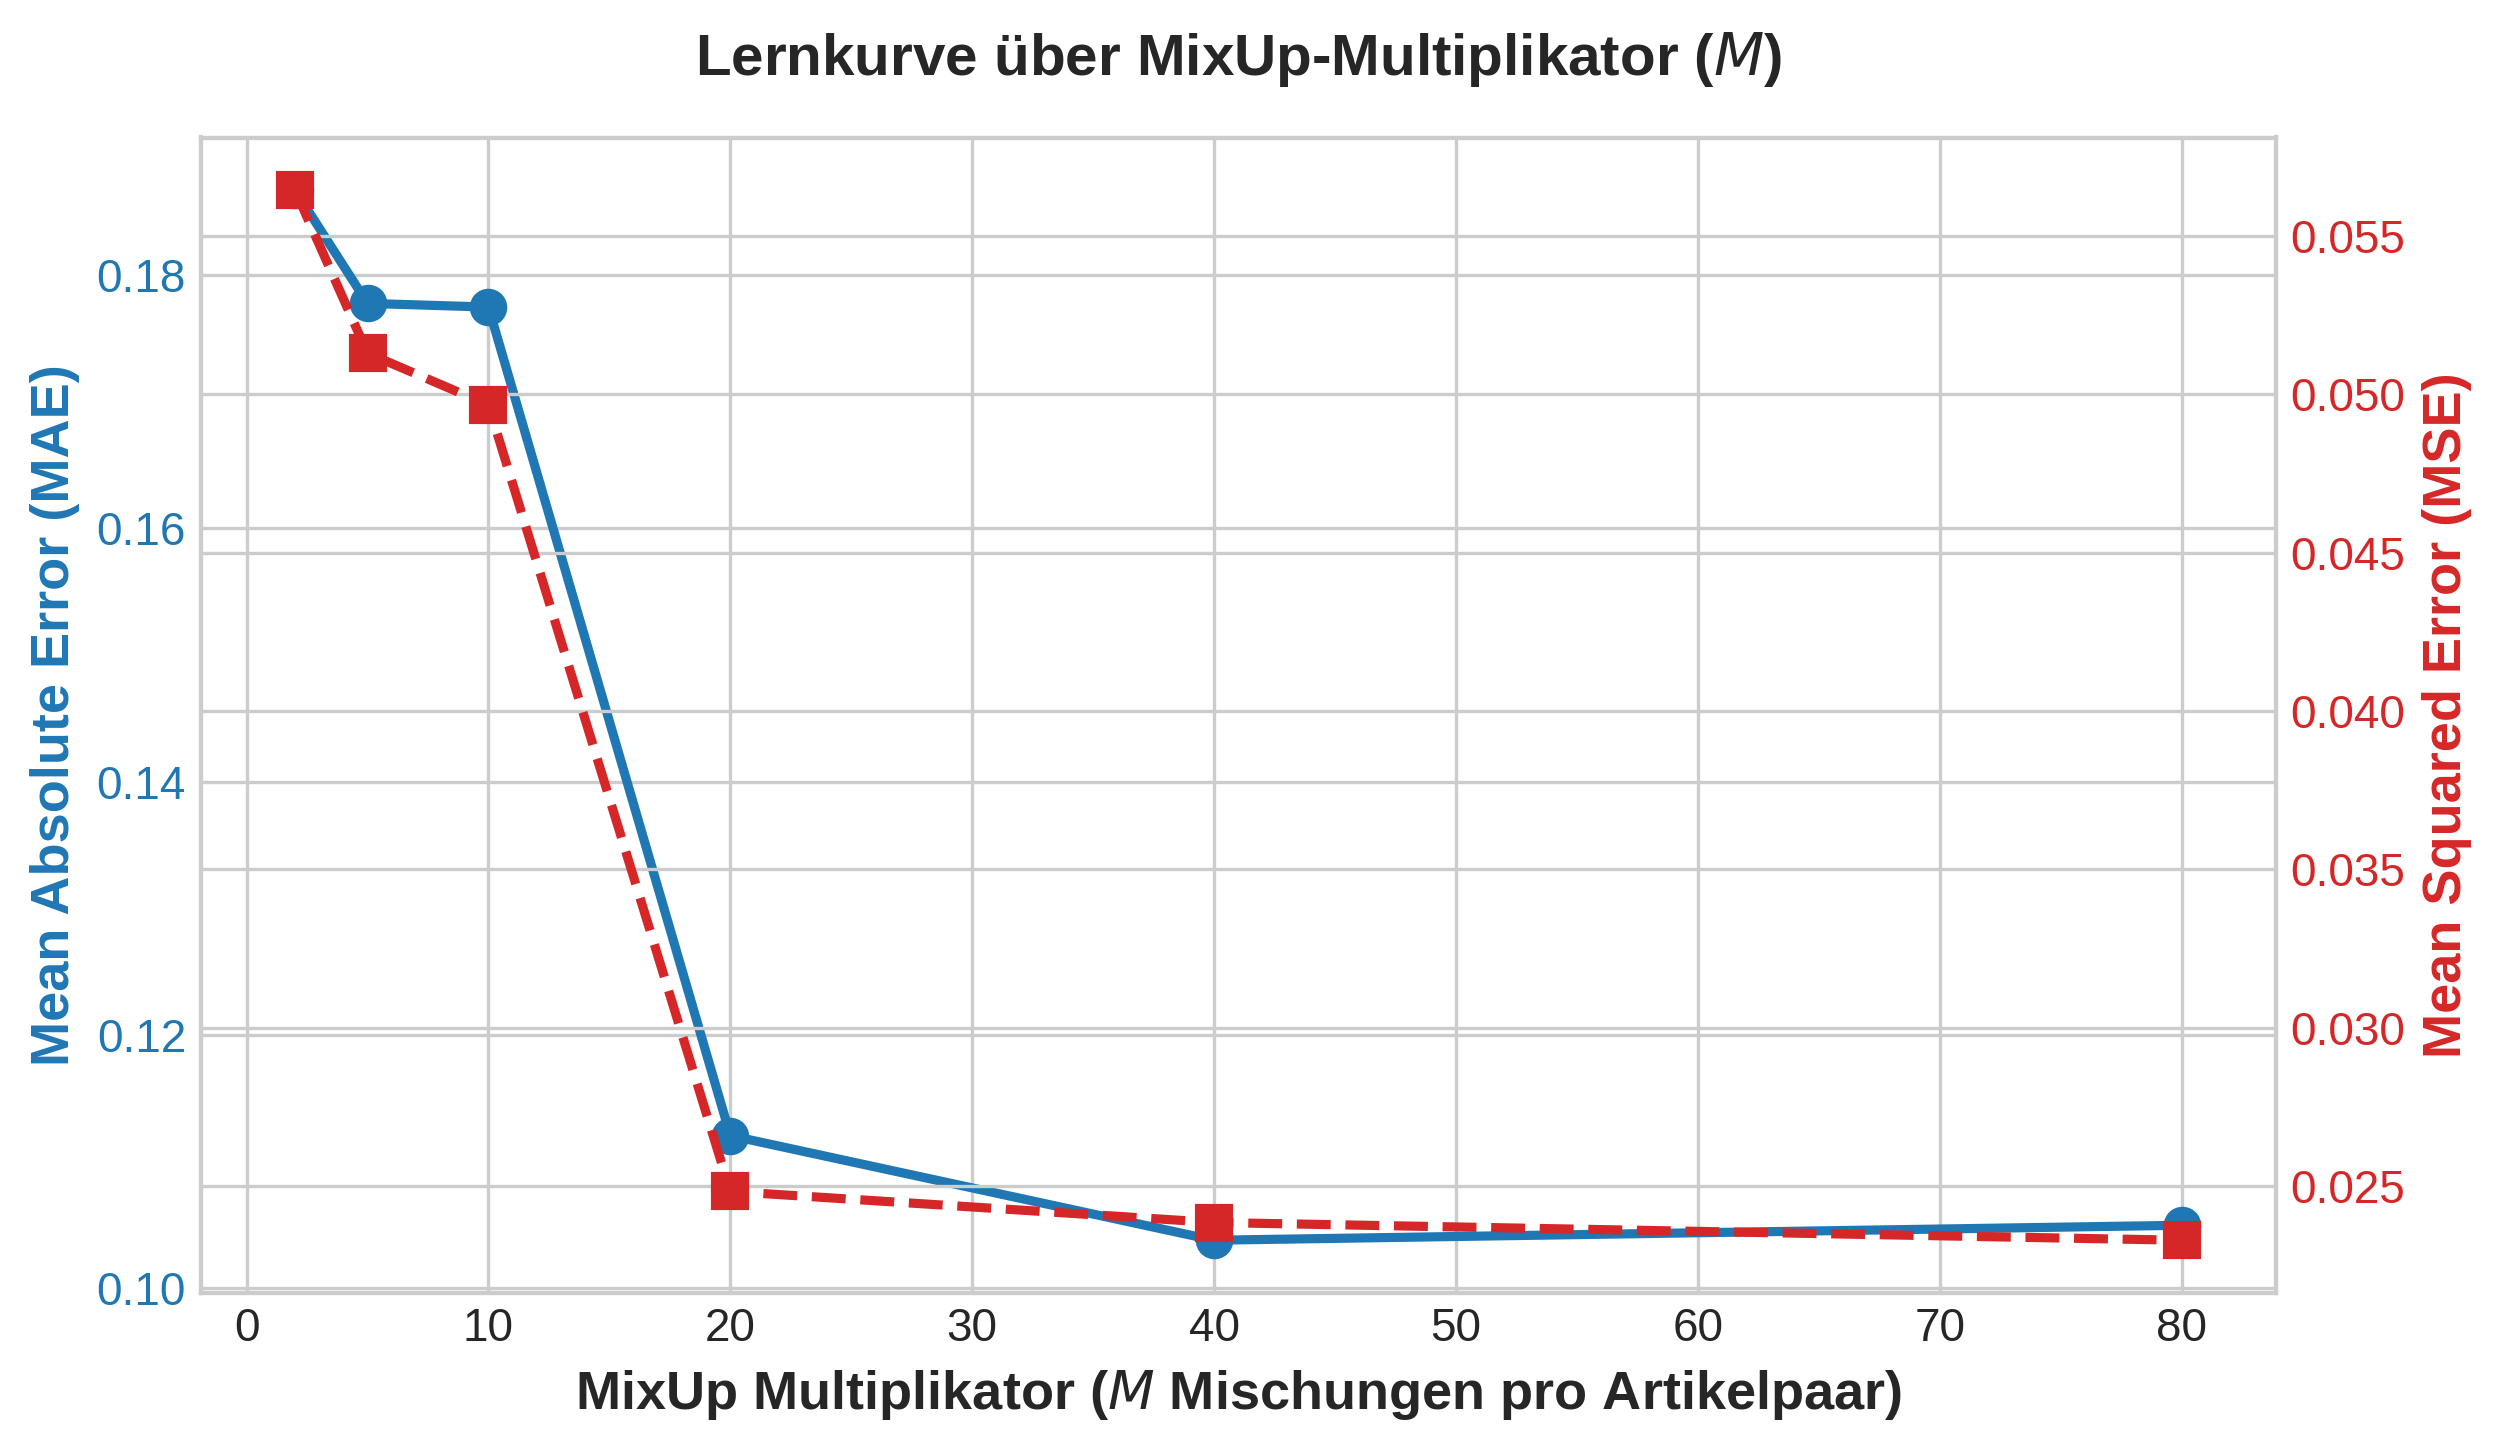

In [3]:
df_mix = df[df["experiment_group"] == "mixtures_scaling"].sort_values("mixtures_per_pair")

if not df_mix.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))

    color_mae = "#1f77b4"
    color_mse = "#d62728"

    ax1.plot(df_mix["mixtures_per_pair"], df_mix["test_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Test MAE")
    ax1.set_xlabel("MixUp Multiplikator ($M$ Mischungen pro Artikelpaar)", fontweight='bold')
    ax1.set_ylabel("Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_mix["mixtures_per_pair"], df_mix["test_mse"], marker='s', markersize=8, linestyle='--', color=color_mse, linewidth=2.2, label="Test MSE")
    ax2.set_ylabel("Mean Squared Error (MSE)", color=color_mse, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_mse)

    plt.title("Lernkurve über MixUp-Multiplikator ($M$)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "mixup_multiplier_learning_curve.png"), dpi=300)
    plt.show()
else:
    print("Keine Daten für 'mixtures_scaling' vorhanden.")

## 3. Dimension 2: Basis-Artikelpaare Skalierung (`num_train_article_pairs`)
Untersucht den Einfluss der Anzahl realer Artikelpaare bei festem MixUp-Multiplikator ($M=20$).

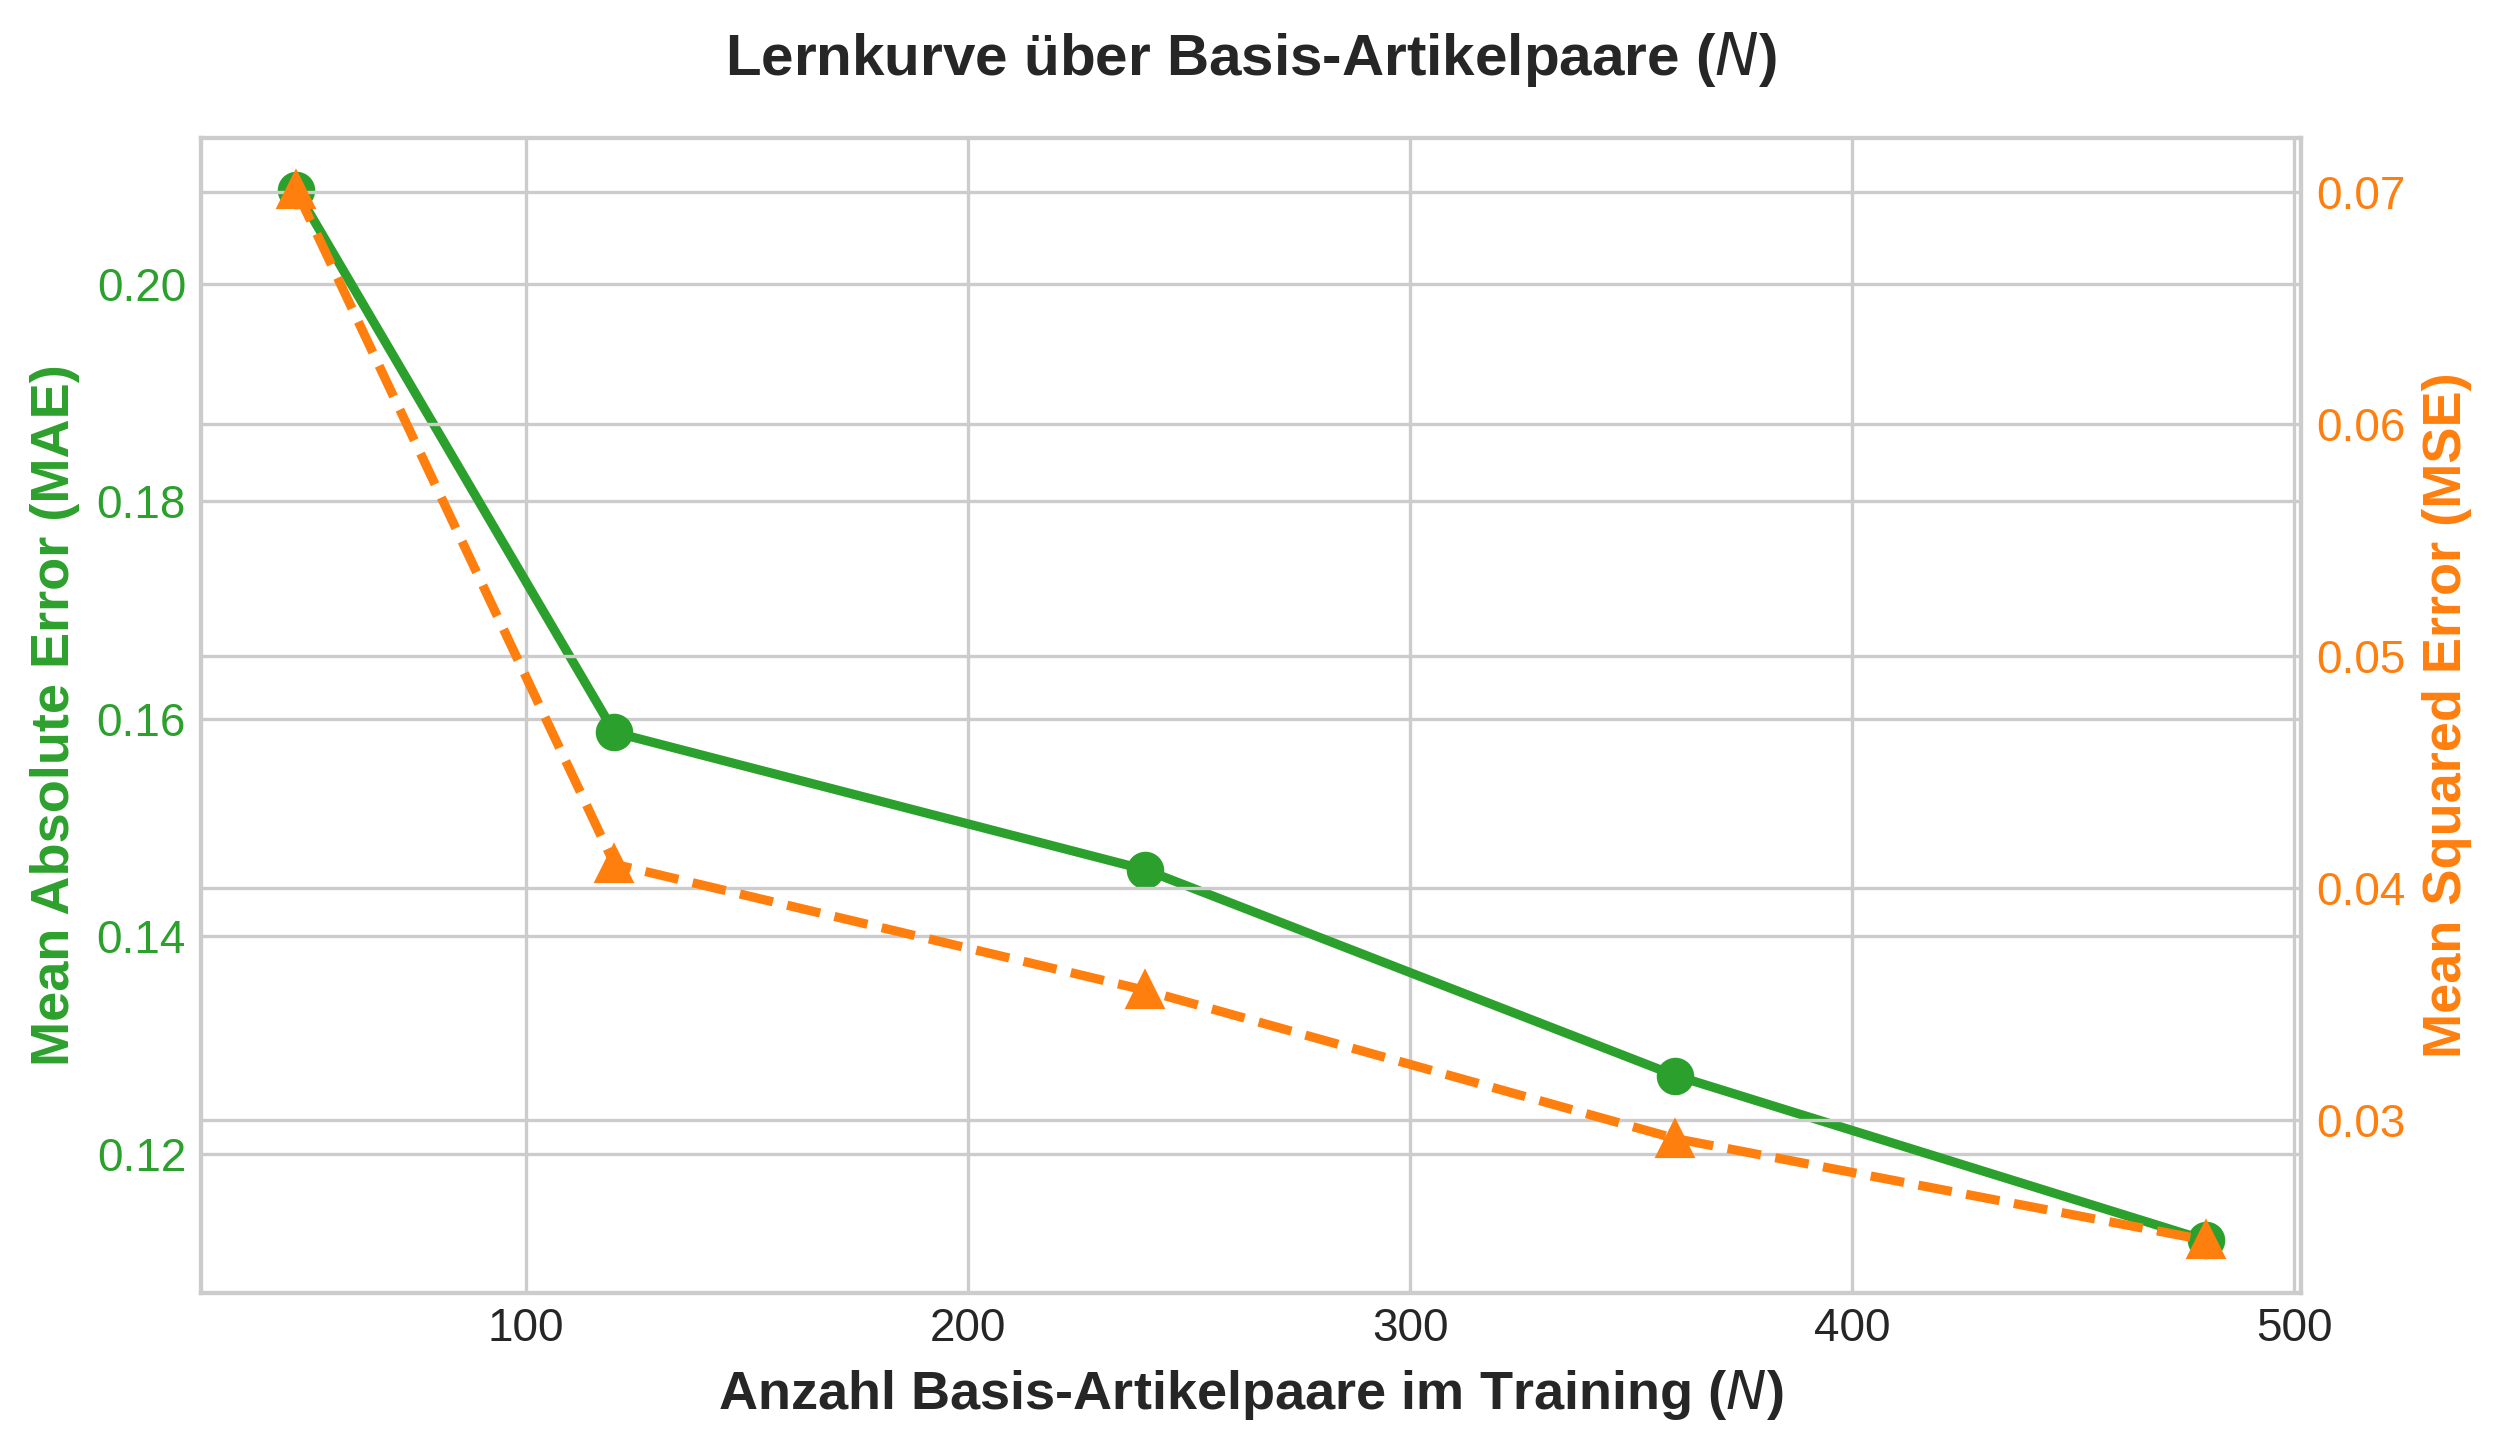

In [4]:
df_pairs = df[df["experiment_group"] == "pairs_scaling"].sort_values("num_train_article_pairs")

if not df_pairs.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))

    color_mae = "#2ca02c"
    color_mse = "#ff7f0e"

    ax1.plot(df_pairs["num_train_article_pairs"], df_pairs["test_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Test MAE")
    ax1.set_xlabel("Anzahl Basis-Artikelpaare im Training ($N$)", fontweight='bold')
    ax1.set_ylabel("Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_pairs["num_train_article_pairs"], df_pairs["test_mse"], marker='^', markersize=8, linestyle='--', color=color_mse, linewidth=2.2, label="Test MSE")
    ax2.set_ylabel("Mean Squared Error (MSE)", color=color_mse, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_mse)

    plt.title("Lernkurve über Basis-Artikelpaare ($N$)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "article_pairs_learning_curve.png"), dpi=300)
    plt.show()
else:
    print("Keine Daten für 'pairs_scaling' vorhanden.")

## 4. Bestimmtheitsmaß ($R^2$) & Korrelationen über die Datenmenge

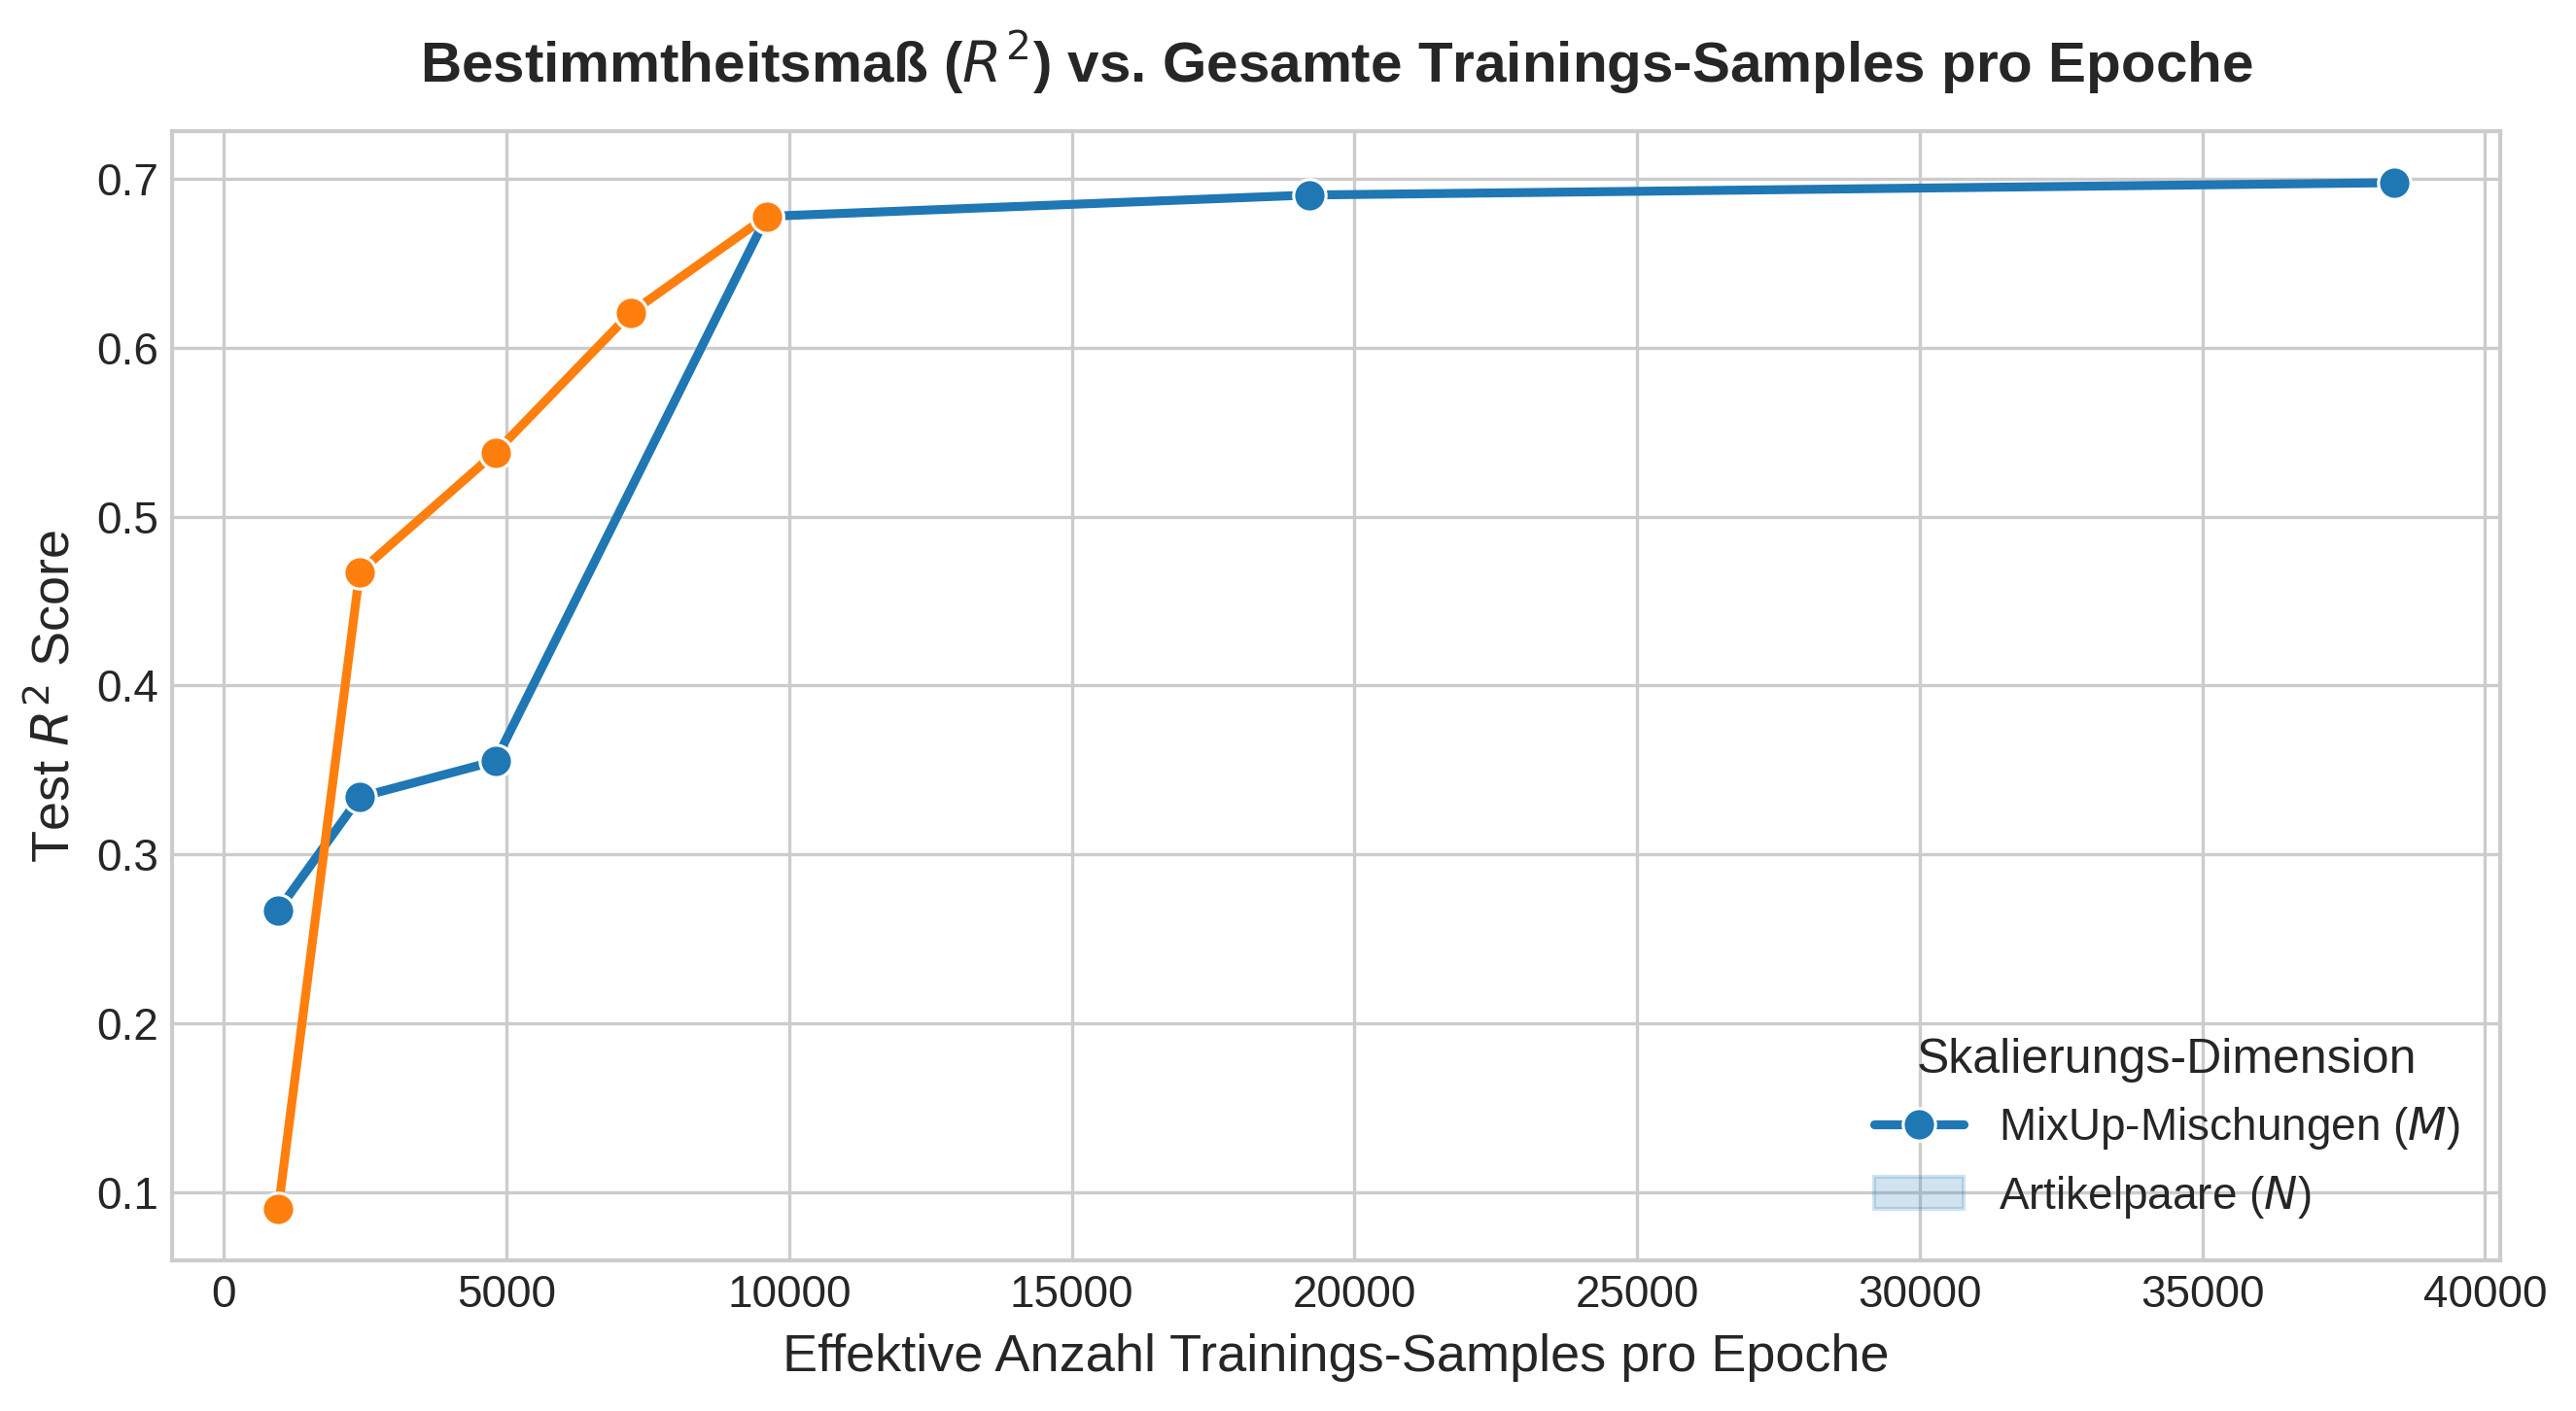

In [5]:
if not df.empty:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df, x="total_train_samples", y="test_r2", hue="experiment_group", marker='o', markersize=8, linewidth=2.2)
    plt.title("Bestimmtheitsmaß ($R^2$) vs. Gesamte Trainings-Samples pro Epoche", pad=12, fontweight='bold')
    plt.xlabel("Effektive Anzahl Trainings-Samples pro Epoche")
    plt.ylabel("Test $R^2$ Score")
    plt.legend(title="Skalierungs-Dimension", labels=["MixUp-Mischungen ($M$)", "Artikelpaare ($N$)"])
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "r2_vs_total_samples.png"), dpi=300)
    plt.show()

## 5. Rechenaufwand vs. Performance-Gewinn (Effizienzanalyse)

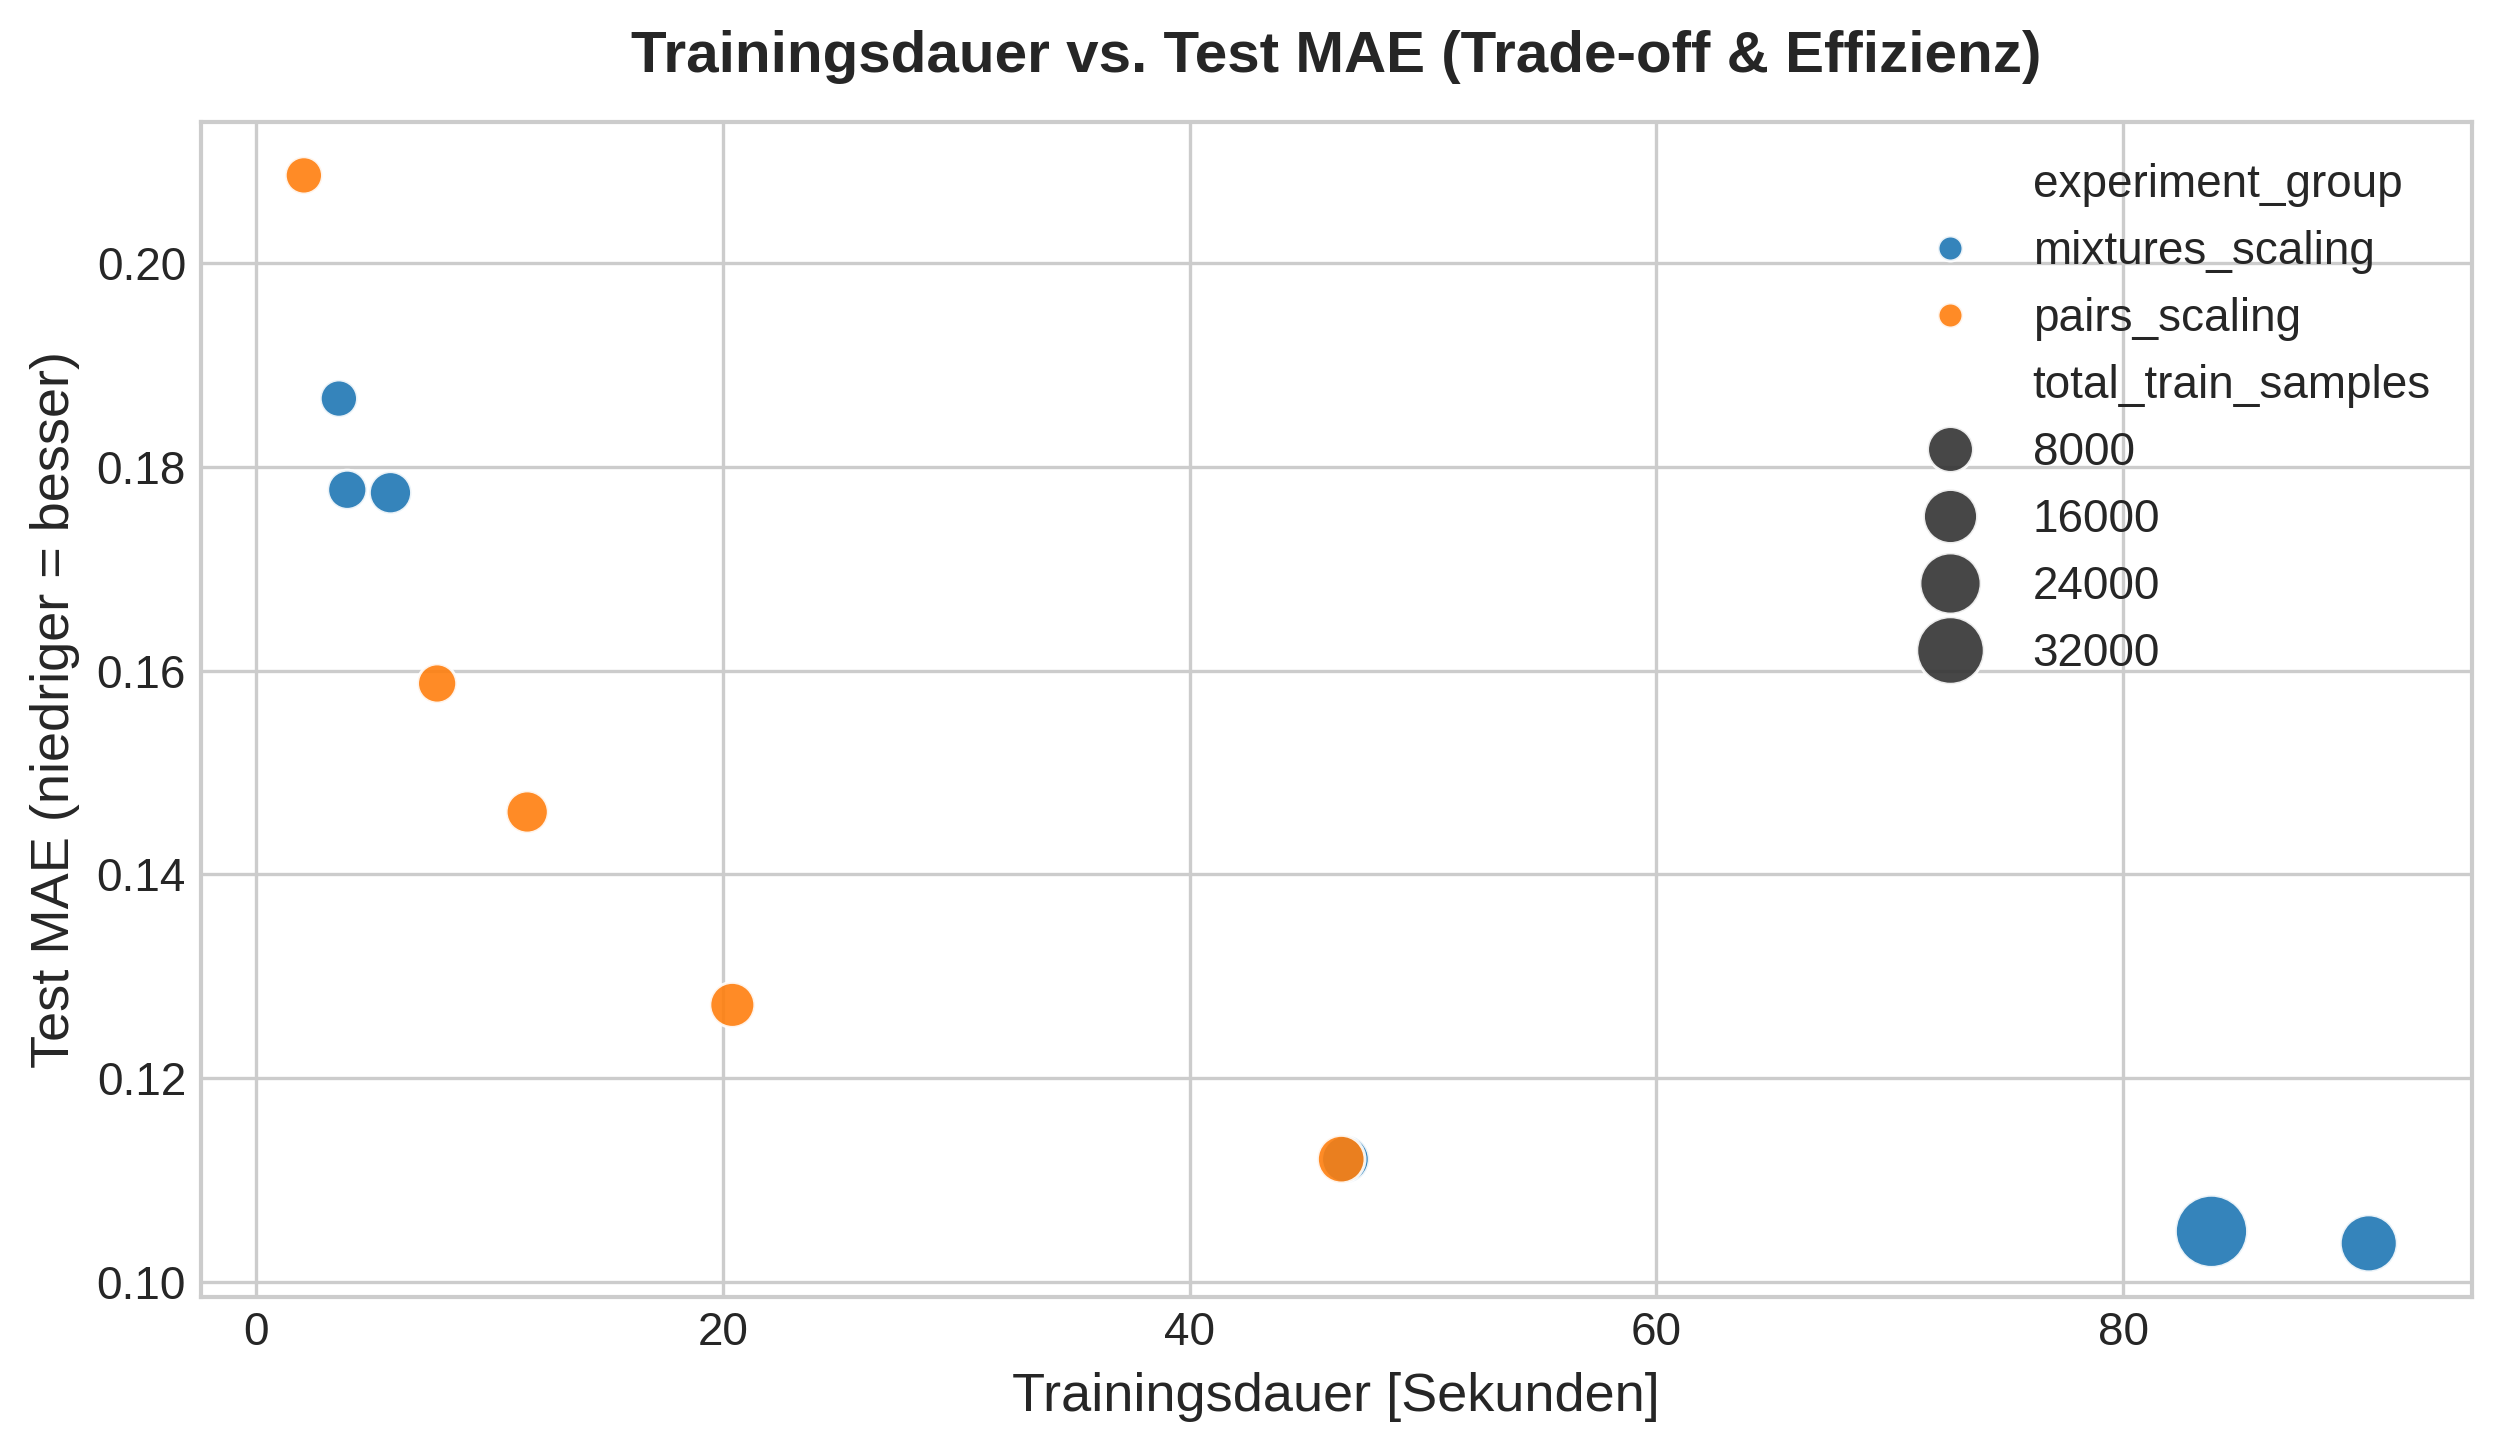

In [6]:
if not df.empty:
    plt.figure(figsize=(8.5, 5))
    sns.scatterplot(
        data=df,
        x="training_time_seconds",
        y="test_mae",
        hue="experiment_group",
        size="total_train_samples",
        sizes=(80, 300),
        alpha=0.9
    )
    plt.title("Trainingsdauer vs. Test MAE (Trade-off & Effizienz)", pad=12, fontweight='bold')
    plt.xlabel("Trainingsdauer [Sekunden]")
    plt.ylabel("Test MAE (niedriger = besser)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "training_time_vs_mae.png"), dpi=300)
    plt.show()